<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-10 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> Simple AutoEncoders with Image Data </h2> </html>

Here is a simple autoencoder with just the dense layers.


Load the data and import the libraries.

In [29]:
# Your code to import matplotlib, pandas and numpy libraries

#
#
#
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

_______________________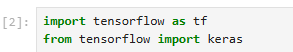

In [30]:
import tensorflow as tf
from tensorflow import keras

In [31]:
print(tf.__version__)

2.20.0


__________________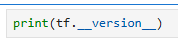

____________________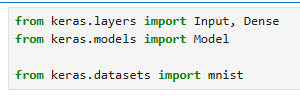

In [32]:
from keras.layers import Input,Dense
from keras.models import Model

from keras .datasets import mnist

In [33]:
# Your code to load MNIST data and store it in variables x_train, x_test. 
# Note -  we do not need labels as it's autoencoder.

#
from tensorflow.keras.datasets import mnist

# Load MNIST data
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.



In [34]:
print(x_train.shape)

(60000, 28, 28)


______________________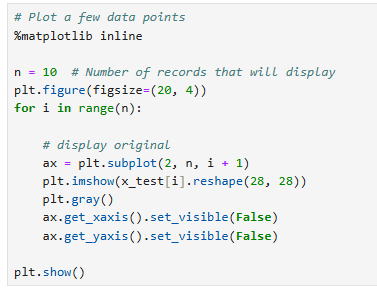

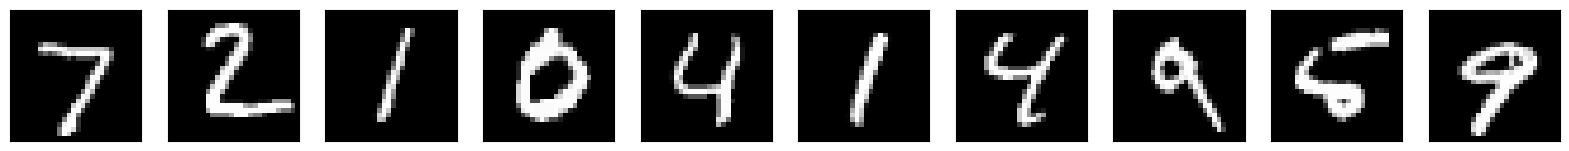

In [35]:
# Plot a few data points

# Only needed in Jupyter Notebook
%matplotlib inline  

n = 10  # Number of images to display
plt.figure(figsize=(20, 4))

for i in range(n):
    
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    
    # remove axis
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [36]:
# Your code to
# normalise train data - Divided by 255
x_train = x_train.astype('float32') / 255.
#

# normalise test data - Divided by 255
x_test = x_test.astype('float32') / 255.
#


<html> <h3 style="font-style:italic; color:blue;"> Basic AutoEncoder : </h3> </html>

Build a basic symmetric encoder-decoder network that recreates the image.  
This network could be used in dimensionaliry reduction or feature learning. 


________________________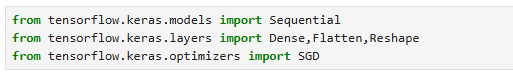

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import SGD

In [38]:
encoder = Sequential()
encoder.add(Flatten(input_shape=[28,28]))

# Add as many layers in the Encoder network of your choice
encoder.add(Dense(128, activation='relu'))
encoder.add(Dense(64, activation='relu'))
#
#
#
#

# The last TWO layers of the Encoder and Decoder must be matched (see the following decoder cell)
encoder.add(Dense(32, activation='relu')) 
#
#


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [39]:
# Your code to print your Encoder model

#
encoder.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
decoder = Sequential()
decoder.add(Dense(50,input_shape=[32],activation='relu'))

# Add as many layers in the Decoder as you want. 
# Reember - Encoder and Decoder must be symmetric.
decoder.add(Dense(64, activation='relu'))
decoder.add(Dense(128, activation='relu'))
#
#
#


decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))


In [41]:
# Your code to print the Decoder model
decoder.summary()
#


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 50)             │         1,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 114,370 (446.76 KB)

 Trainable params: 114,370 (446.76 KB)

 Non-trainable params: 0 (0.00 B)

____________________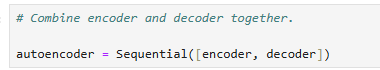

In [42]:
autoencoder = Sequential([encoder, decoder])

In [43]:
# Your code to print the Autoencoder model
autoencoder.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_8 (Sequential)       │ (None, 28, 28)         │       114,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,186 (879.63 KB)

 Trainable params: 225,186 (879.63 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
#SGD?
from tensorflow.keras.optimizers import SGD

autoencoder.compile(
    loss='binary_crossentropy',
    optimizer=SGD(learning_rate=0.01)
)

In [45]:
# Your code to compile the Autoencoder. 
# Use binary_crossenropy as loss and metrics as accuracy.
autoencoder.compile(
    loss='binary_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)



___________________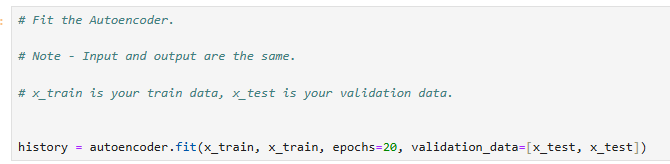

In [47]:
# Fit the Autoencoder

# Note - Input and output are the same
# x_train is your training data, x_test is your validation data

history = autoencoder.fit(x_train, x_train,epochs=20,validation_data=(x_test, x_test))

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0679 - loss: 0.0044 - val_accuracy: 0.0688 - val_loss: 0.0044
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0693 - loss: 0.0043 - val_accuracy: 0.0696 - val_loss: 0.0044
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0699 - loss: 0.0043 - val_accuracy: 0.0703 - val_loss: 0.0043
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0704 - loss: 0.0043 - val_accuracy: 0.0713 - val_loss: 0.0043
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0709 - loss: 0.0042 - val_accuracy: 0.0717 - val_loss: 0.0043
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0704 - loss: 0.0042 - val_accuracy: 0.0705 - val_loss: 0.0042
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.0703 - loss: 0.0042 - val_accuracy: 0.0705 - val_loss: 0.0042
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0703 - loss: 0.0042 - 

____________________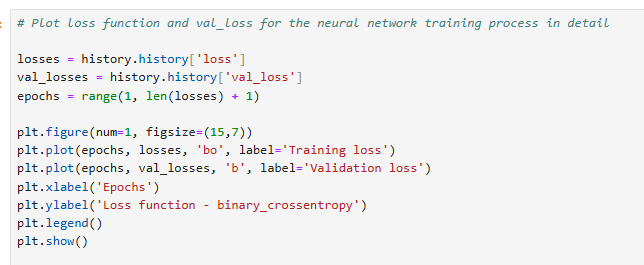

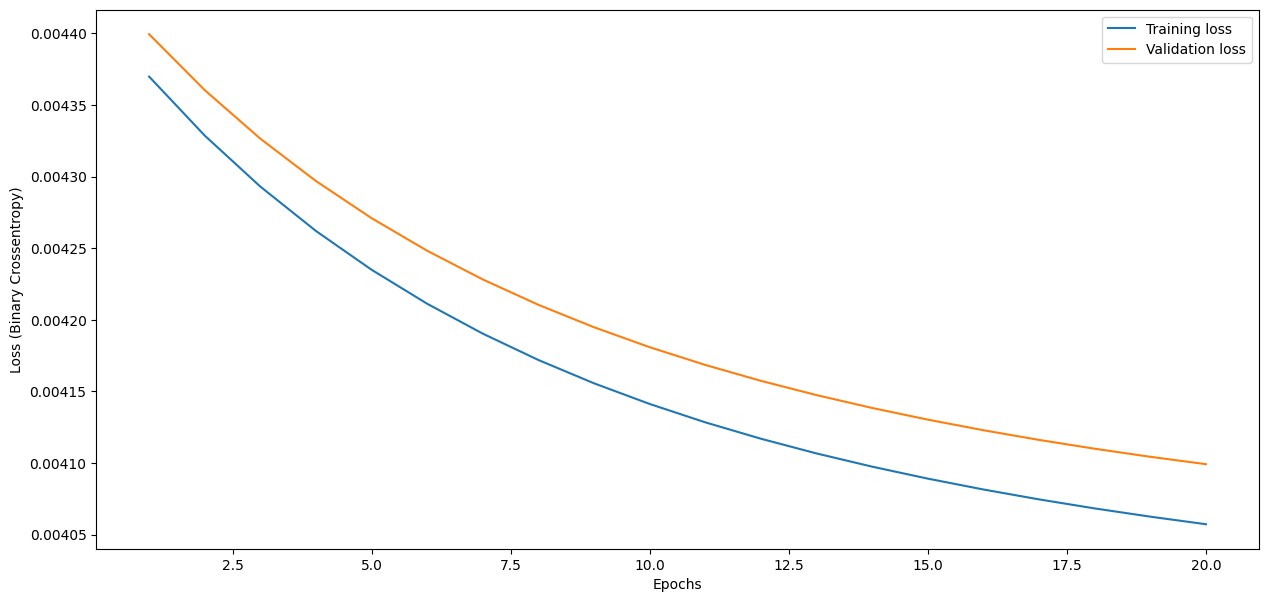

In [48]:
# Plot loss function and validation loss

losses = history.history['loss']
val_losses = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(figsize=(15, 7))

plt.plot(epochs, losses, label='Training loss')
plt.plot(epochs, val_losses, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()

plt.show()

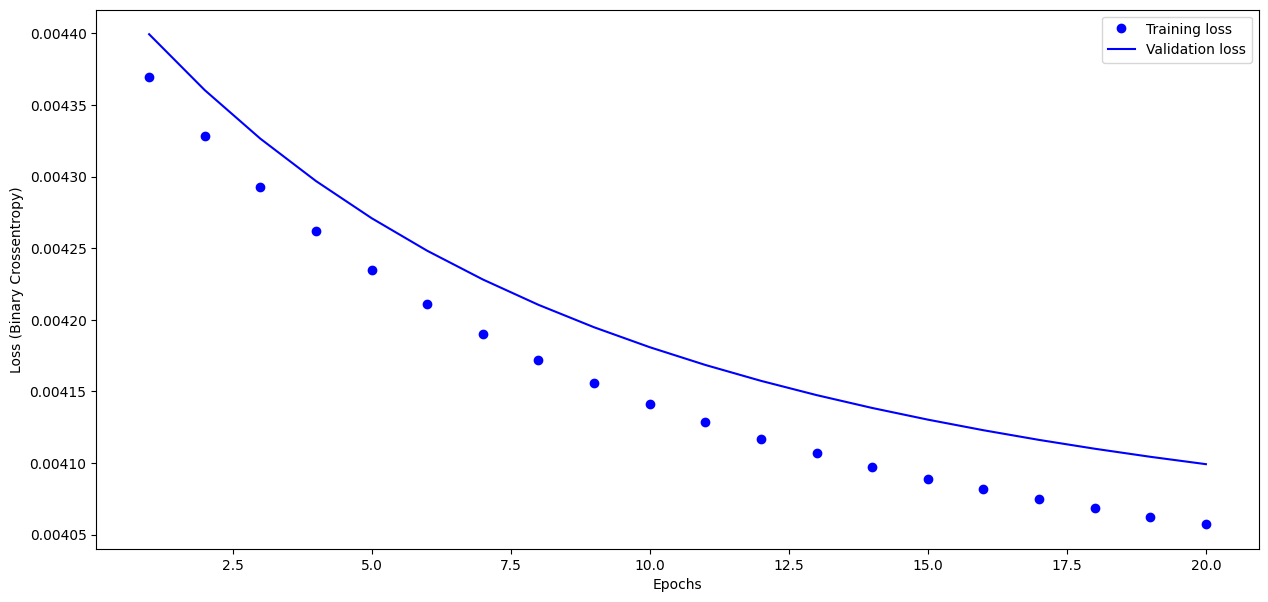

In [49]:
losses = history.history['loss']
val_losses = history.history['val_loss']
epochs = range(1, len(losses) + 1)

plt.figure(figsize=(15, 7))

# Training loss → blue dots
plt.plot(epochs, losses, 'bo', label='Training loss')

# Validation loss → blue line
plt.plot(epochs, val_losses, 'b', label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()

plt.show()

___________________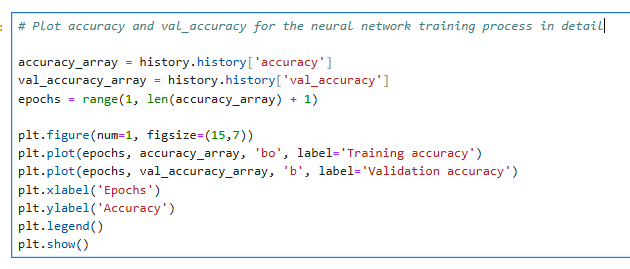

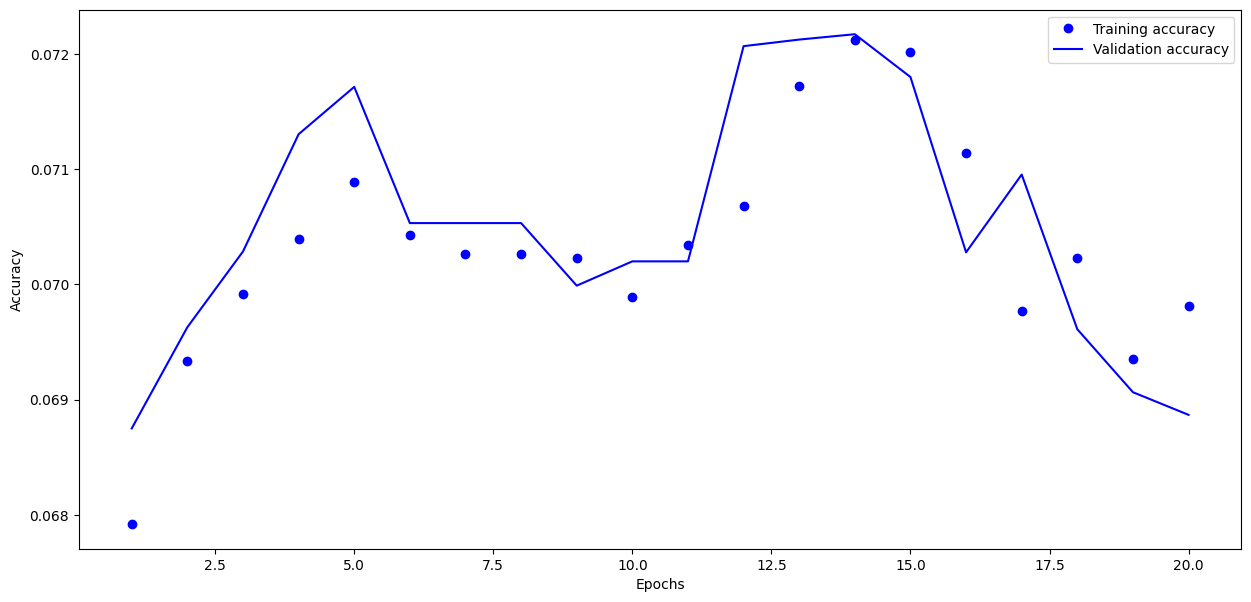

In [50]:
# Plot accuracy and validation accuracy

accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']

epochs = range(1, len(accuracy_array) + 1)

plt.figure(figsize=(15, 7))

# Training accuracy → blue dots
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')

# Validation accuracy → blue line
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

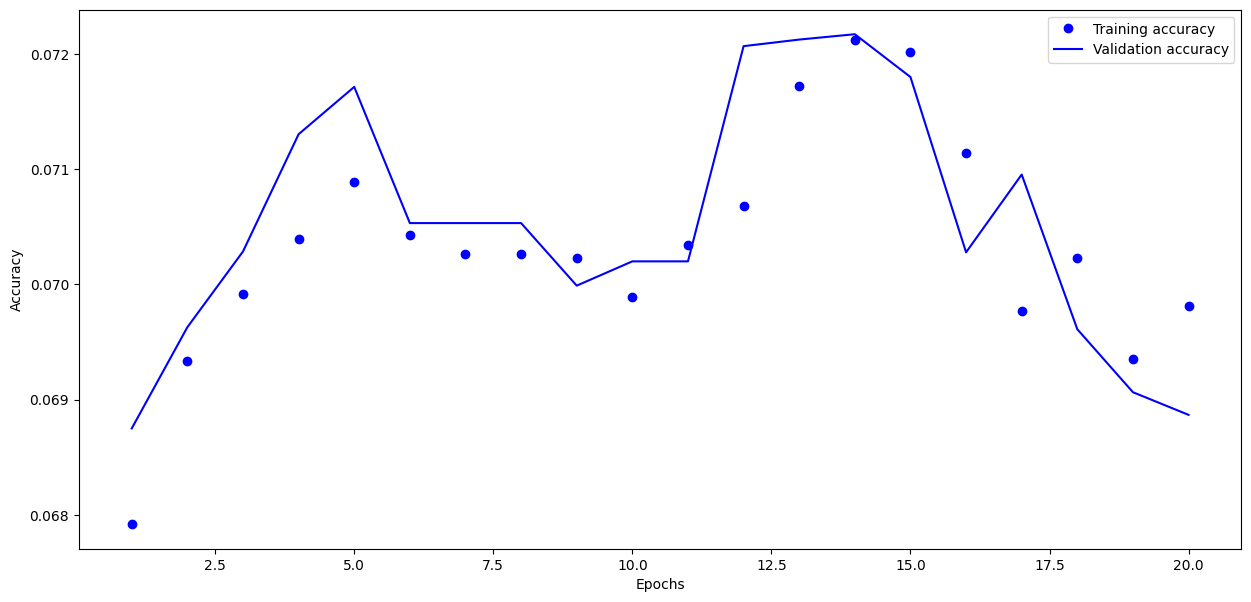

In [51]:
accuracy_array = history.history['accuracy']
val_accuracy_array = history.history['val_accuracy']

epochs = range(1, len(accuracy_array) + 1)

plt.figure(figsize=(15, 7))

# Training accuracy → blue dots
plt.plot(epochs, accuracy_array, 'bo', label='Training accuracy')

# Validation accuracy → blue line
plt.plot(epochs, val_accuracy_array, 'b', label='Validation accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

_______________________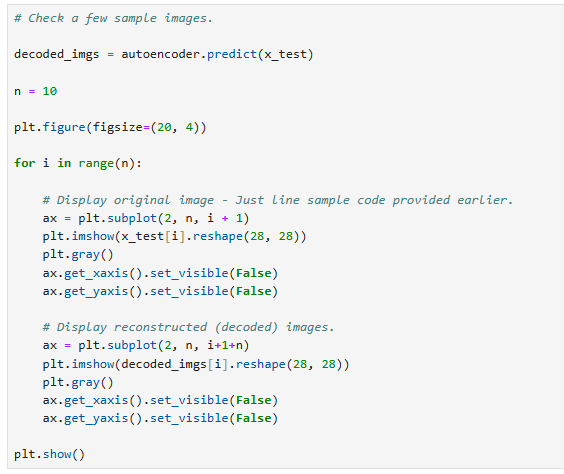

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


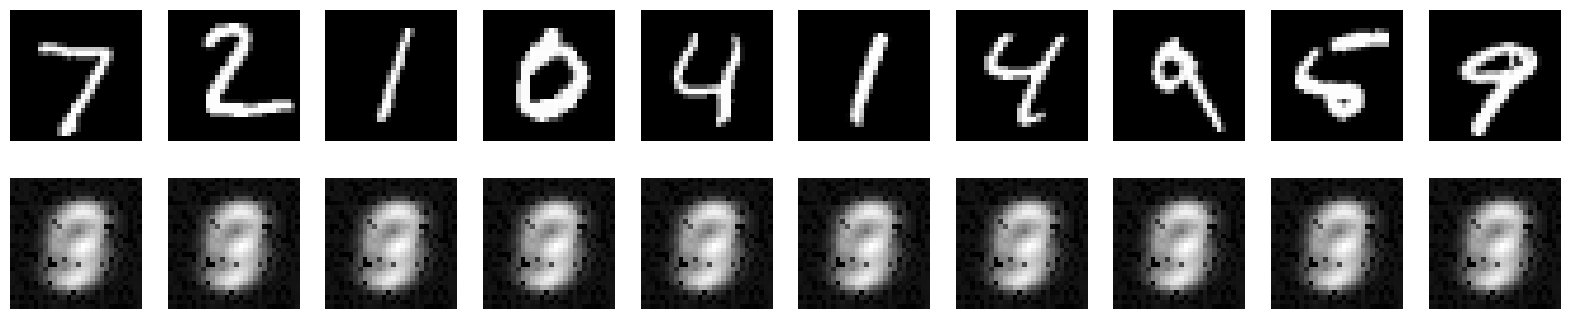

In [52]:
# Predict reconstructed images
decoded_imgs = autoencoder.predict(x_test)

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')   
    ax.axis('off')

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i], cmap='gray')  
    ax.axis('off')

plt.show()

<html> <h3 style="font-style:italic; color:blue;"> AutoEncoders for Denoising Images : </h3> </html>

Use the same digit data set. Add Gaussian noise to it to train an autoencoder that removes noise. Test the noisy samples. 


______________________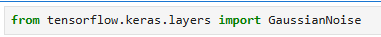

In [54]:
from tensorflow.keras.layers import GaussianNoise

In [ ]:
#GaussianNoise?

___________________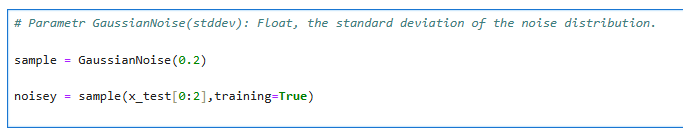

In [55]:
from tensorflow.keras.layers import GaussianNoise

sample = GaussianNoise(0.2)

noisy = sample(x_test[0:2], training=True)

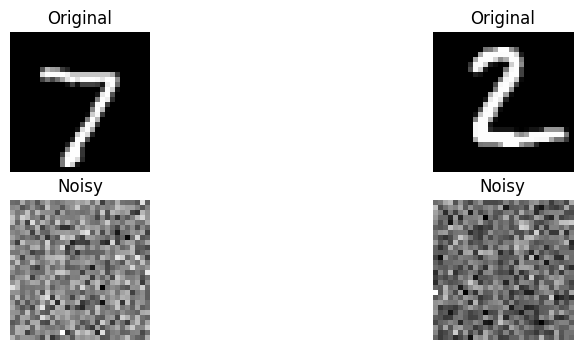

In [56]:
# Plot the original and noisy images
n = 2  # number of samples

plt.figure(figsize=(10, 4))

for i in range(n):

    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    ax.set_title("Original")
    ax.axis('off')

    # Noisy images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(noisy[i], cmap='gray')
    ax.set_title("Noisy")
    ax.axis('off')

plt.show()

_______________________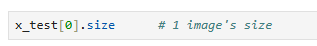

In [57]:
x_test[0].size

784

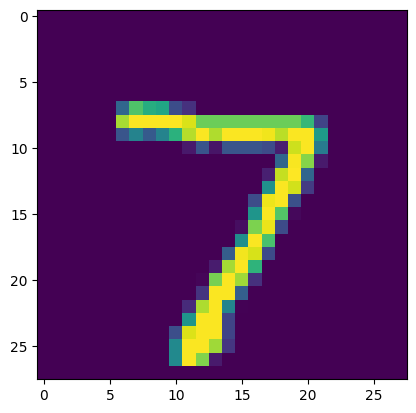

In [58]:
plt.imshow(x_test[0])
plt.show()

____________________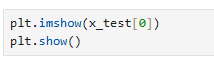

_____________________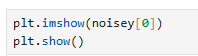

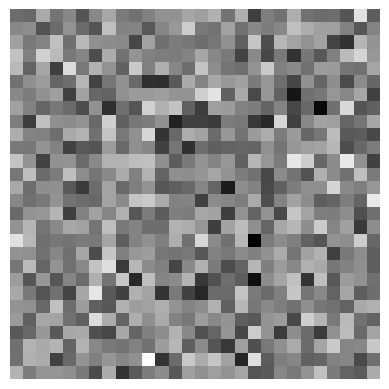

In [60]:
plt.imshow(noisy[0], cmap='gray')
plt.axis('off')
plt.show()

_________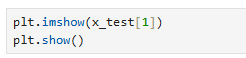

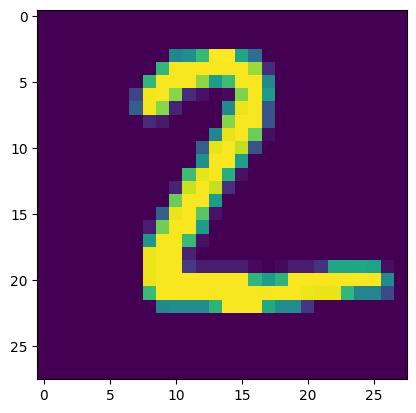

In [61]:
plt.imshow(x_test[1])
plt.show()

______________________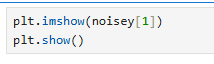

<html> <h4 style="font-style:italic; color:blue;"> Create a noise removal autoencoder and train it </h4> </html>

- Again similar to above it is a symmetric dense network. 
- Gaussian noise is added at the input so that the network sees noisy images and is able to map it to the clean outputs.


### Input - Images with noise
### Labels - Clean images.


In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GaussianNoise

encoder = Sequential()
encoder.add(Flatten(input_shape=[28, 28]))

# Add noise (for denoising autoencoder)
encoder.add(GaussianNoise(0.2))

# Encoder layers (same pattern as before)
encoder.add(Dense(128, activation='relu'))
encoder.add(Dense(64, activation='relu'))
encoder.add(Dense(32, activation='relu'))  # latent space

print(encoder.summary())

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 784)            │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

None


In [65]:
decoder = Sequential()
decoder.add(Dense(50, input_shape=[32], activation='relu'))

decoder.add(Dense(64, activation='relu'))
decoder.add(Dense(128, activation='relu'))

decoder.add(Dense(28 * 28, activation="sigmoid"))
decoder.add(Reshape([28, 28]))

_________________________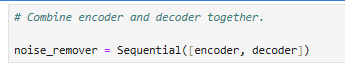

In [66]:
noise_remover = Sequential([encoder, decoder])

In [67]:
# Your code to print the Autoencoder model

#
noise_remover.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_10 (Sequential)      │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (None, 28, 28)         │       114,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,186 (879.63 KB)

 Trainable params: 225,186 (879.63 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
# Your code to compile the 'noise_remover' model with the same parameters as earlier

# noise_remover.compile( ................  )
from tensorflow.keras.optimizers import SGD

noise_remover.compile(
    loss='binary_crossentropy',
    optimizer=SGD(learning_rate=0.01),
    metrics=['accuracy']
)

In [69]:
# Your code to fit 'noise_remover' model with the same parameters as earlier

# history_2 = ..........................
history_2 = noise_remover.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_test, x_test)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0412 - loss: 0.6924 - val_accuracy: 0.0277 - val_loss: 0.6923
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0414 - loss: 0.6914 - val_accuracy: 0.0277 - val_loss: 0.6915
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0414 - loss: 0.6905 - val_accuracy: 0.0276 - val_loss: 0.6906
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0404 - loss: 0.6895 - val_accuracy: 0.0276 - val_loss: 0.6897
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0391 - loss: 0.6885 - val_accuracy: 0.0277 - val_loss: 0.6888
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0381 - loss: 0.6874 - val_accuracy: 0.0281 - val_loss: 0.6878
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.0369 - loss: 0.6863 - val_accuracy: 0.0283 - val_loss: 0.6868
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0358 - loss: 0.6851 - val_accu

In [ ]:
# Hint: Use (copy and modify) the code from the cells above

___________________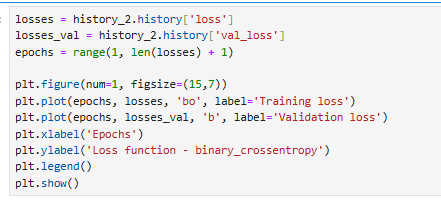

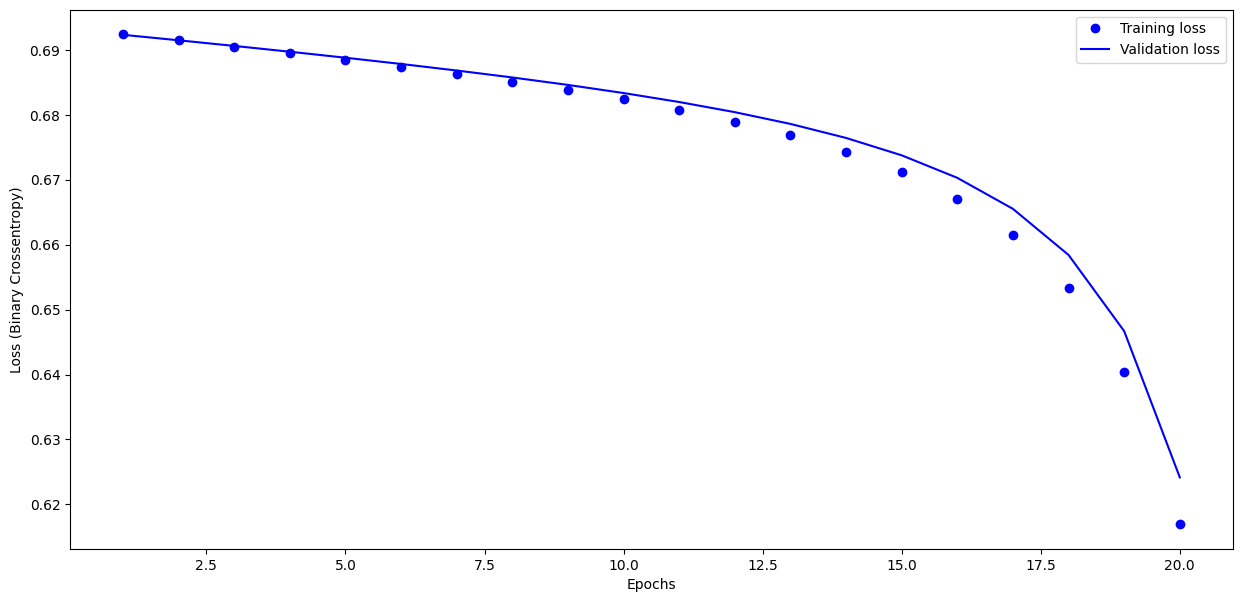

In [70]:
losses = history_2.history['loss']
val_losses = history_2.history['val_loss']

epochs = range(1, len(losses) + 1)

plt.figure(figsize=(15, 7))

# Training loss → blue dots
plt.plot(epochs, losses, 'bo', label='Training loss')

# Validation loss → blue line
plt.plot(epochs, val_losses, 'b', label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Crossentropy)')
plt.legend()

plt.show()

___________________________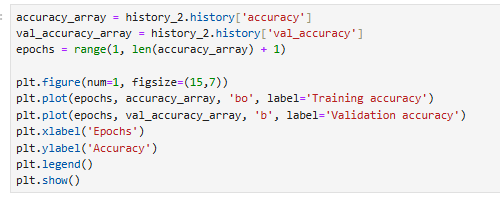

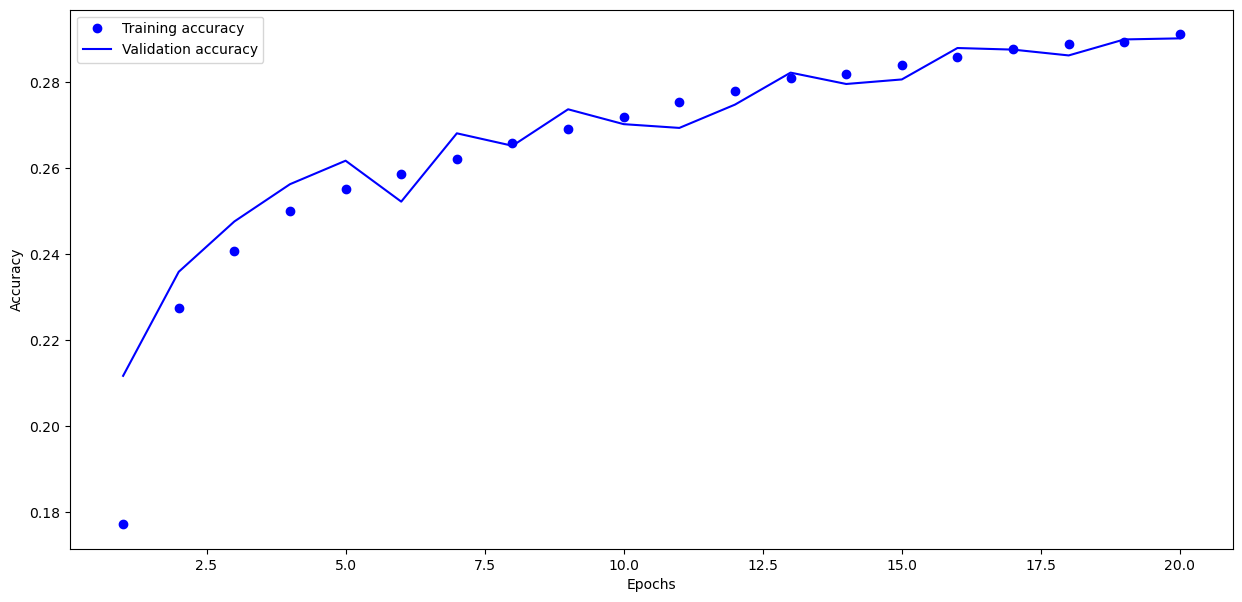

______________________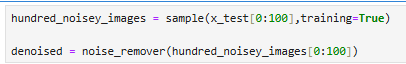

In [71]:
hundred_noisy_images = sample(x_test[0:100], training=True)

denoised = noise_remover.predict(hundred_noisy_images)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


______________________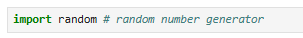

In [72]:
import random

_______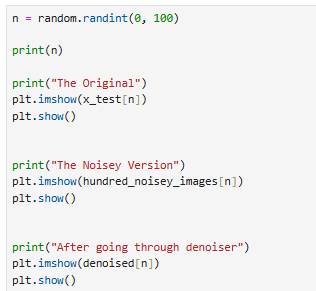

24
The Original


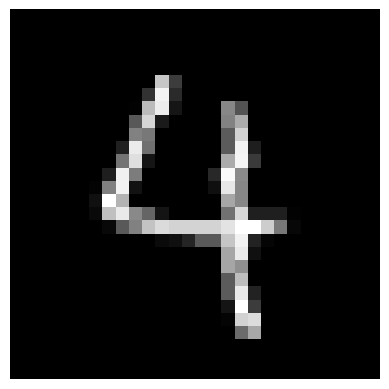

The Noisy Version


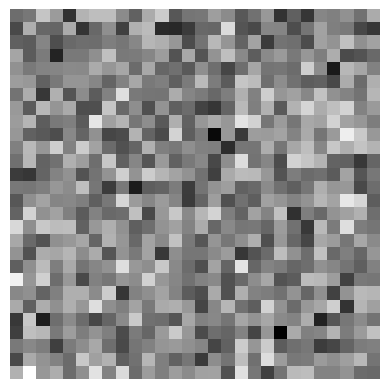

After going through denoiser


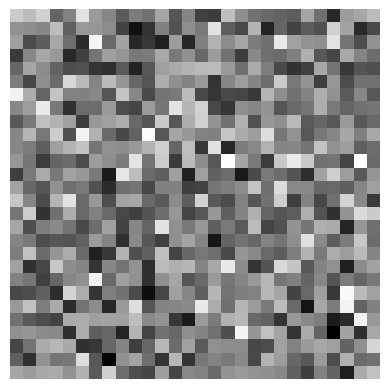

In [73]:
import random

n = random.randint(0, 99)  # safe range

print(n)

print("The Original")
plt.imshow(x_test[n], cmap='gray')
plt.axis('off')
plt.show()

print("The Noisy Version")
plt.imshow(hundred_noisy_images[n], cmap='gray')
plt.axis('off')
plt.show()

print("After going through denoiser")
plt.imshow(denoised[n], cmap='gray')
plt.axis('off')
plt.show()

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

 - Put the Encoder, Decoder and Basic Autoencoder models using summary() in your lab logbook.

Ensure that no code or other information is added to the logbook and that only required information is present. Marks will not be awarded if anything else is found in the logbook or instructions are not clearly followed.

NOTE: DON'T FORGET TO SAVE AND BACK UP YOUR COMPLETED JUPYTER NOTEBOOK AND LAB LOGBOOK ON GITHUB OR ONEDRIVE.